# GNNs for Automated Feature Engineering

## Manual Feature Engineering

Feature engineering is a pivotal process in machine learning, *involving the selection, creation, and transformation of input variables* to enhance model performance. It entails tasks such as feature selection to identify essential variables, creating new features to capture complex relationships, and handling data preprocessing tasks like encoding categorical variables or scaling values. *This process heavily relies on domain expertise and evolves over time to adapt to changing data dynamics, ultimately ensuring that machine learning models are equipped with the most relevant and informative features for accurate predictions and insights.*

**In the Mini Project on Graph ML, we performed manual feature engineering on the Stanford Facebook Dataset for clustering Graph nodes.**

## Automated Feature Engineering through Supervised Neural Networks

Neural networks excel not only in learning complex patterns but also in automating feature engineering. Rather than manually designing features, neural networks can process raw data and derive informative representations automatically. For instance, in image classification, Convolutional Neural Networks (CNNs) can learn essential image features such as edges, textures, and shapes directly from pixel values. Similarly, Recurrent Neural Networks (RNNs) are proficient at capturing sequential patterns, making them suitable for natural language processing tasks where they can extract meaningful features from text data. Neural networks, with their ability to discover intricate relationships and abstractions within data, have revolutionized feature engineering by streamlining the process and achieving state-of-the-art results across various domains.

**One common methodology for feature extraction using neural networks involves training a Neural Network Classifier on a labeled dataset, feeding the raw data into the trained classifier, and utilizing the outputs from intermediate layers as the extracted features. This approach formulates the problem as a supervised classification task.**

This process is reminiscent of the **AutoEncoder** architecture for Feature Extraction. *However, in cases where labeled data is not available, as was the situation with the AutoEncoder, the output remains the same as the input, and during training, the model learns useful representations of the input data that can be considered as extracted features.*

## Graph Neural Networks for Automated Feature Engineering on Graph Data

Graph Neural Networks (GNNs) have emerged as a powerful tool for feature extraction in various domains, particularly where data is structured as graphs. GNNs excel in capturing complex relationships and patterns within graph-structured data, making them valuable for tasks like recommendation systems, social network analysis, and molecule property prediction. Instead of relying on manually crafted features, GNNs learn feature representations directly from the graph structure and node attributes. They propagate information between connected nodes through multiple layers, iteratively refining node embeddings.

**In this exercise, we will learn how to use a GNN for extracting node features, and later use the engineered node features for clustering, just like in the Mini ML Project.**

*This notebook is designed to help you guide how to approach this assignment.*

<i><font color='blue'>Some parts of the notebook are left as exercise for you and are the corresponding headers are marked in blue</font></i>

# Dataset

We will use the same "Stanford Facebook" Dataset as used in the Mini ML Project. The Dataset contains links between several nodes (users) in a Social Network.

## Install and Importing the required libraries

In [ ]:
!pip3 install torch_geometric igraph

In [ ]:
from google.colab import drive
from torch_geometric.utils import from_networkx
import torch
import numpy as np
import torch_geometric.transforms as T
import networkx as nx

from sklearn.metrics import roc_auc_score
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

## Mount Google Drive, and download the dataset

In [ ]:
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
!wget -P /content/gdrive/MyDrive/gnn-data  https://snap.stanford.edu/data/facebook_combined.txt.gz
!cd /content/gdrive/MyDrive/gnn-data && gunzip facebook_combined.txt.gz

--2023-09-01 09:48:10--  https://snap.stanford.edu/data/facebook_combined.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218576 (213K) [application/x-gzip]
Saving to: ‘/content/gdrive/MyDrive/gnn-data/facebook_combined.txt.gz’

facebook_combined.t 100%[===================>] 213.45K   546KB/s    in 0.4s    

2023-09-01 09:48:10 (546 KB/s) - ‘/content/gdrive/MyDrive/gnn-data/facebook_combined.txt.gz’ saved [218576/218576]



## Let's construct the Graph using the connections (Edge) list in the dataset

<font color='blue'>Write code to load the dataset from the txt file. Your code should finally return a torch_geometric Data Object</font>

In [ ]:
import igraph
ig_graph = igraph.Graph.Read_Edgelist('/content/gdrive/MyDrive/gnn-data/facebook_combined.txt', directed=False)
nx_graph = ig_graph.to_networkx()
data = from_networkx(nx_graph)

The Dataset contains no node features. It only contains a list of connections/edge between various nodes, denoting a real connection in the social network.

But a GNN, just like any other Neural Network, needs some encoded inputs to work on.

Let's utilize node adjacency information as input features to the GNN.

<font color='blue'>Write code to generate adjacency matrix on the graph</font>

In [ ]:
adj_matrix = nx.adjacency_matrix(nx_graph)
adj_matrix.shape

(4039, 4039)

Now adding these features to the graph

In [ ]:
data.x = torch.tensor(adj_matrix.toarray(), dtype=torch.float32)

In [ ]:
data.x

tensor([[0., 1., 1.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

# Learning Node Embeddings through a Supervised GNN

**Objective of Node Embeddings:**

The primary goal of node embeddings is to represent nodes features (adjacency information) in a lower-dimensional space where similar nodes in the original graph are closer to each other in the embedding space, and dissimilar nodes are farther apart. This representation should capture the structural and relational information present in the graph.

**Detecting Edge Presence:**

One way to evaluate the quality of node embeddings and how well they capture relationships is by assessing their ability to predict the presence or absence of edges in the original graph.
If an edge exists between two nodes in the original graph, it's expected that their corresponding embeddings in the lower-dimensional space should be close to each other or have a high similarity.
Conversely, if there is no edge between two nodes in the original graph, their embeddings should be relatively farther apart or have a lower similarity.

**Edge Presence in Embedding Space:**

The presence of an edge in the graph obtained from the node embeddings can be an indicator of how well the embeddings capture the original graph's structure. If the embeddings are effective, you would expect edges to exist in the embedding-based graph for node pairs with strong structural relationships in the original graph.

<u>Therefore, we will formulate this problem as a link prediction problem</u>.

We will use the adjacency features we just created, in order to train a GNN which would predicts links between the input nodes.

## Encoder-Decoder Architecture for Link Prediction

An Encoder-Decoder based GNN is often used for Link Prediction problem.

In the context of edge detection or link prediction, you want to determine whether there should be an edge (connection) between two nodes or not.

The encoder-decoder architecture can be used to achieve this by using the learned node embeddings:

Encoder: The encoder part of the model takes the graph structure and node embeddings as input and encodes this information into meaningful node representations in the embedding space. This encoding step captures the similarity between nodes based on their embeddings.

Decoder: The decoder takes pairs of node embeddings (corresponding to two nodes in the graph) as input and produces a prediction of whether there should be an edge between those nodes or not. This prediction is based on the similarity captured in the embeddings.

Refer to example here for reference: https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py . Notice the usage of an encoder-decoder architecture.

<font color='blue'>Write code to split the Graph into Train, Validation and Test using T.Compose</font>

In [ ]:
transform = T.Compose([
    T.NormalizeFeatures(),
    T.RandomLinkSplit(num_val=0.05, num_test=0.1, is_undirected=True,
                      add_negative_train_samples=False),
])
train_data, val_data, test_data = transform(data)

In [ ]:
train_data.x

tensor([[0.0000, 0.0029, 0.0029,  ..., 0.0000, 0.0000, 0.0000],
        [0.0588, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]])

### The GNN

<font color='blue'>Write the GNN for Link Prediction. </font>

Refer to the following example from torch_geomtric:
https://github.com/pyg-team/pytorch_geometric/blob/master/examples/link_pred.py

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def decode_all(self, z):
        prob_adj = z @ z.t()
        return (prob_adj > 0).nonzero(as_tuple=False).t()

<font color='blue'> Now write code to train the model. Experiment with various hyperparameters such as output dimensions, number of epochs etc. Also experiment with different model architectures but increasing or decreasing the number of hidden layers and neurons in each layer. </font>

In [ ]:
input_dimension = data.num_features
hidden_dimension = 32
output_dimension = 16
num_epochs = 20

learning_rate = 0.01

model = Net(input_dimension, hidden_dimension, output_dimension)
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
criterion = torch.nn.BCEWithLogitsLoss()


def train():
    model.train()
    optimizer.zero_grad()
    z = model.encode(train_data.x, train_data.edge_index)

    # We perform a new round of negative sampling for every training epoch:
    neg_edge_index = negative_sampling(
        edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1), method='sparse')

    edge_label_index = torch.cat(
        [train_data.edge_label_index, neg_edge_index],
        dim=-1,
    )
    edge_label = torch.cat([
        train_data.edge_label,
        train_data.edge_label.new_zeros(neg_edge_index.size(1))
    ], dim=0)

    out = model.decode(z, edge_label_index).view(-1)
    loss = criterion(out, edge_label)
    loss.backward()
    optimizer.step()
    return loss


@torch.no_grad()
def test(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).view(-1).sigmoid()
    return roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())


best_val_auc = final_test_auc = 0
for epoch in range(1, num_epochs):
    loss = train()
    val_auc = test(val_data)
    test_auc = test(test_data)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        final_test_auc = test_auc
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}, '
          f'Test: {test_auc:.4f}')

print(f'Final Test: {final_test_auc:.4f}')

z = model.encode(test_data.x, test_data.edge_index)
final_edge_index = model.decode_all(z)

Epoch: 001, Loss: 0.6931, Val: 0.9152, Test: 0.9167
Epoch: 002, Loss: 0.6916, Val: 0.8971, Test: 0.8972
Epoch: 003, Loss: 0.6862, Val: 0.8906, Test: 0.8900
Epoch: 004, Loss: 0.6755, Val: 0.8851, Test: 0.8838
Epoch: 005, Loss: 0.6591, Val: 0.8789, Test: 0.8768
Epoch: 006, Loss: 0.6395, Val: 0.8743, Test: 0.8715
Epoch: 007, Loss: 0.6215, Val: 0.8759, Test: 0.8730
Epoch: 008, Loss: 0.6059, Val: 0.8868, Test: 0.8845
Epoch: 009, Loss: 0.5866, Val: 0.9051, Test: 0.9040
Epoch: 010, Loss: 0.5629, Val: 0.9231, Test: 0.9230
Epoch: 011, Loss: 0.5396, Val: 0.9361, Test: 0.9358
Epoch: 012, Loss: 0.5179, Val: 0.9456, Test: 0.9446
Epoch: 013, Loss: 0.4987, Val: 0.9517, Test: 0.9505
Epoch: 014, Loss: 0.4806, Val: 0.9554, Test: 0.9542
Epoch: 015, Loss: 0.4668, Val: 0.9576, Test: 0.9567
Epoch: 016, Loss: 0.4590, Val: 0.9590, Test: 0.9584
Epoch: 017, Loss: 0.4591, Val: 0.9603, Test: 0.9597
Epoch: 018, Loss: 0.4616, Val: 0.9618, Test: 0.9611
Epoch: 019, Loss: 0.4663, Val: 0.9632, Test: 0.9621
Final Test: 

<font color='blue'> Now use the model to generate embeddings on the entire dataset </font>

In [ ]:
# Assuming you have already trained your 'model' and have access to it

# Put the model in evaluation mode
model.eval()

# Encode the data to obtain the final hidden layer representations
z = model.encode(data.x, data.edge_index)

In [ ]:
z.shape

torch.Size([4039, 16])

<font color='blue'> Now try out various clustering algorithms on the node embeddings and find out the optimal number of clusters using elbow plot. Calculate various metrics such as silhouette score, Calinski-Harabasz index, and Davies-Bouldin index for each cluster size. Also create plots for metrics used against the number of clusters.
</font>

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

z_np = z.cpu().detach().numpy()

# Specify the range of number of clusters to consider
min_clusters = 2
max_clusters = 50

# Lists to store silhouette scores for the data and cluster counts
silhouette_scores_test = []
cluster_counts = list(range(min_clusters, max_clusters + 1))

within_sum = []

# Iterate over different numbers of clusters
for num_clusters in cluster_counts:
    # Perform KMeans clustering on the GNN embeddings
    kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init = 'auto')
    cluster_assignments = kmeans.fit_predict(z_np)

    # Calculate silhouette score
    silhouette_avg_test = silhouette_score(z_np, cluster_assignments)
    silhouette_scores_test.append(silhouette_avg_test)
    within_sum.append(kmeans.inertia_)

Optimal Clusters: 17


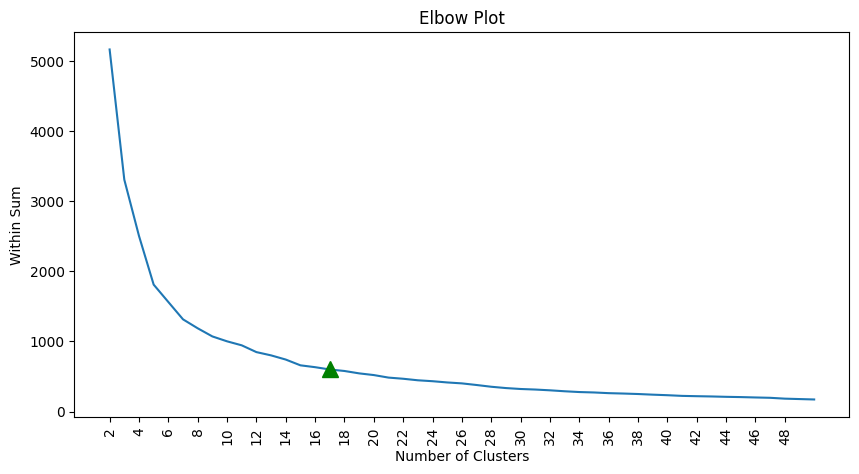

In [ ]:
plt.figure(figsize = (10,5))
plt.plot(range(min_clusters, max_clusters+1), within_sum)
plt.xlabel('Number of Clusters')
plt.ylabel('Within Sum')
plt.title('Elbow Plot')
plt.xticks(range(min_clusters, max_clusters, 2), rotation=90)


plt.plot(17, within_sum[15],'g^', markersize = 12)
print('Optimal Clusters:',17)

Plot silhouette_score vs num clusters

Number of clusters with Best Silhouette Score: 5


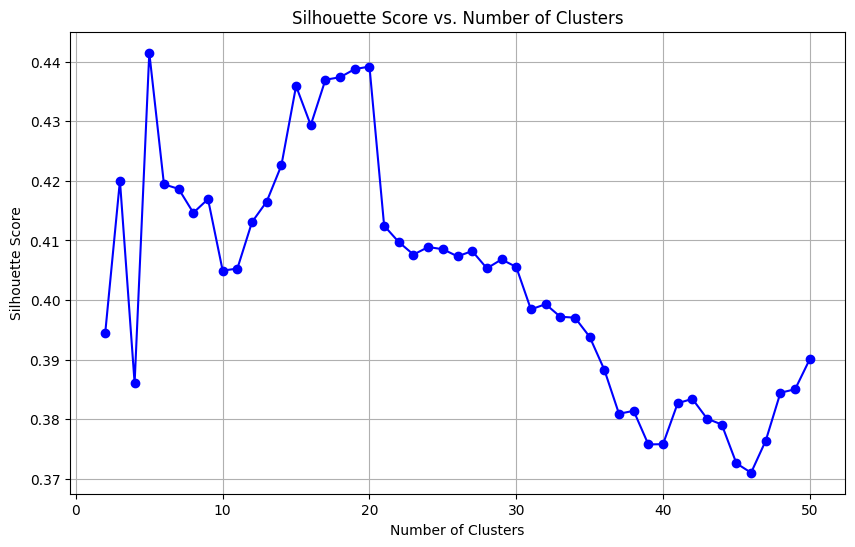

In [ ]:
# Find the number of clusters with the highest silhouette score
optimal_num_clusters_test = silhouette_scores_test.index(max(silhouette_scores_test)) + min_clusters
print(f"Number of clusters with Best Silhouette Score: {optimal_num_clusters_test}")

# Plot silhouette scores vs. cluster counts
plt.figure(figsize=(10, 6))
plt.plot(cluster_counts, silhouette_scores_test, marker='o', linestyle='-', color='b')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. Number of Clusters")
plt.grid(True)
plt.show()

# Summary

<font color='blue'>Summarize the steps taken and your observations in comparison to the manual featuring engineering performed in Mini ML Project on Graph ML.</font>

< Not adding any answer here, since the observations and steps will be subjective to Mini ML Project done by each learner>

<font color='blue'>Summarize the steps taken and your observations in comparison to the feature extraction done using AutoEncoders for downstream classification task.</font>

< Not adding any answer here, since the observations and steps will be subjective to AutoEncoder assignment done by each learner>